In [1]:
%matplotlib notebook
import torch
import torch.nn as nn
import torch.optim as optim
from dimensionality_reduction import AE, AETrainer

C:\Users\gwb21218\Miniconda3\envs\dm2\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ae = AE(1,64)
optimi = optim.Adam(ae.parameters(), lr=1e-2, weight_decay=1e-6)
sched = optim.lr_scheduler.StepLR(optimi, 50)
loss_fn = nn.MSELoss()

In [3]:
trainer = AETrainer(ae, optimi, loss_fn, 200, 6, "training_data_15.npz", scheduler=None)

In [4]:
%%time
trainer.load_data()

CPU times: total: 50.6 s
Wall time: 50.7 s


<IPython.core.display.Javascript object>


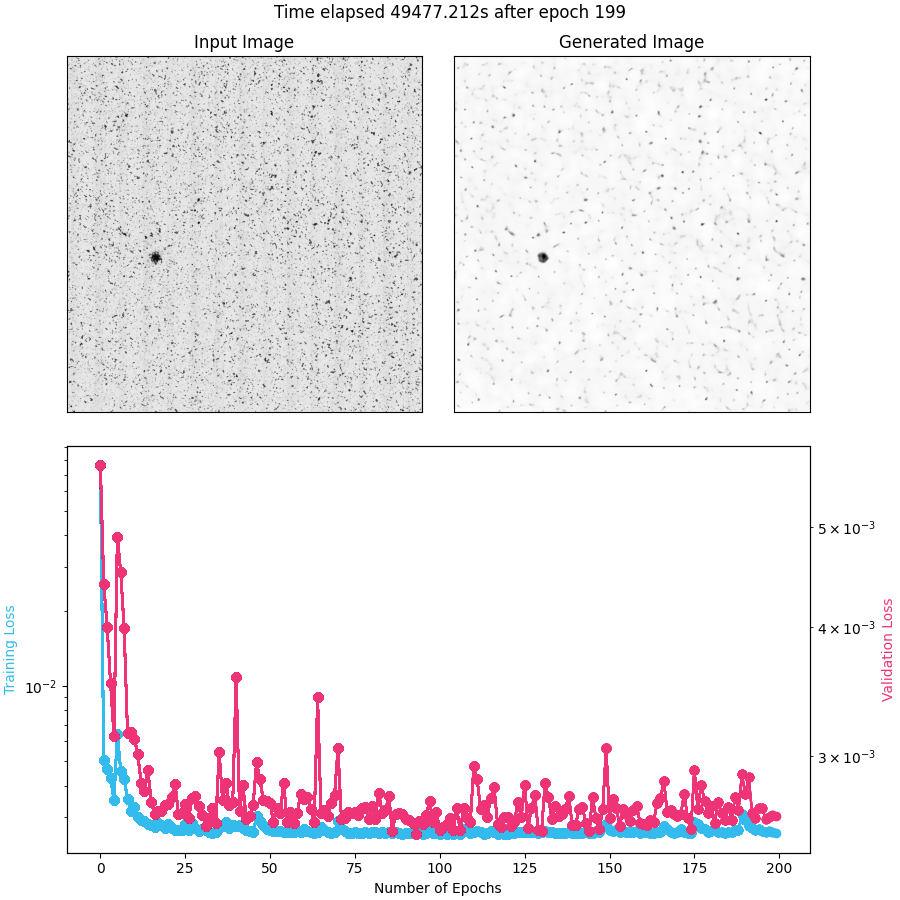

100%|████████████████████████████████████████████████████████████████████████████████| 336/336 [03:47<00:00,  1.47it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 336/336 [03:35<00:00,  1.56it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 336/336 [03:34<00:00,  1.56it/s]


In [5]:
trainer.myth_trainer()

In [ ]:
ae.load_state_dict(torch.load("199_no_scheduler_1e-2.pth")["model_state_dict"])

In [6]:
with torch.no_grad():
    out = ae(torch.from_numpy(trainer.val_in[-1]/255).unsqueeze(0).unsqueeze(0).float().cuda()).squeeze().cpu().numpy()

In [7]:
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>


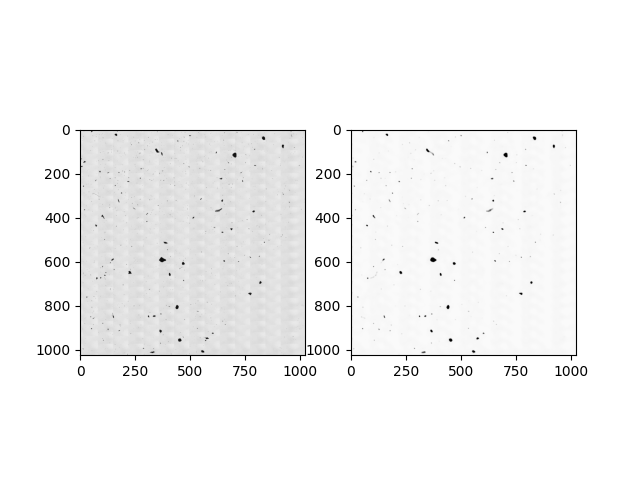

In [8]:
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(trainer.val_in[-1], cmap="Greys_r")
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(out, cmap="Greys_r")

In [12]:
import numpy as np

In [14]:
trainer.train_losses[-1]

0.0025897049345076084

In [17]:
trainer.val_losses[-1]

tensor(0.0026)